In [1]:
!pip install scipy -q

In [131]:
"""
Fit crystallization-kinetics models to beta-hematin conversion data.

Expected input file format:
    time   conversion   sigma(optional)

Example:
    0    4.7   4.0
    0.5  24.1   6.7
    ...

If the third column is NOT an uncertainty estimate, set USE_SIGMA = False.
"""

from __future__ import annotations

import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Iterable

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# =========================
# User settings
# =========================
DATA_FILE = Path("/home/sgaviria/MalariaProject/notebooks/beta-hematina.txt")
USE_SIGMA = True          # use 3rd column as sigma (uncertainty) if available
MAKE_PLOT = False #True
SAVE_PLOT = False #True
PLOT_FILE = Path("beta_hematina_fits.png")
RANDOM_SEED = 123

# Bounds can be adjusted if your data are in % or fraction.
# Here we assume conversion is in percent (0-100).
Y_MIN, Y_MAX = 0.0, 120.0


# =========================
# Models
# =========================
def avrami(t: np.ndarray, A0: float, k: float, n: float) -> np.ndarray:
    """Avrami / Johnson-Mehl-Avrami-Kolmogorov style conversion curve."""
    t = np.asarray(t, dtype=float)
    return A0 * (1.0 - np.exp(-k * np.power(t, n)))


def pasternack(
    t: np.ndarray, y0: float, y1: float, y2: float, k: float, ks: float, n: float
) -> np.ndarray:
    """
    Pasternack et al. model as written in the thesis:
        Y = y0 - y1 exp(-k t^n) - y2 exp(-ks t)
    """
    t = np.asarray(t, dtype=float)
    return y0 - y1 * np.exp(-k * np.power(t, n)) - y2 * np.exp(-ks * t)


def second_order_thesis(
    t: np.ndarray, alpha: float, k1: float, beta: float, k2: float, D: float
) -> np.ndarray:
    """
    Second-order + logistic model as written in the thesis:
        Y = alpha - alpha/(alpha*k1*t + 1) + beta/(1 + exp(-(beta*k2*t + D)))
    """
    t = np.asarray(t, dtype=float)
    return alpha - alpha / (alpha * k1 * t + 1.0) + beta / (1.0 + np.exp(-(beta * k2 * t + D)))


# Optional: a numerically more stable reparameterization of the second-order model
# if you need y(0) closer to the measured initial conversion.
def second_order_shifted(
    t: np.ndarray, alpha: float, k1: float, beta: float, k2: float, D: float
) -> np.ndarray:
    """
    Same structure as the thesis model but shifted so the logistic contribution
    is zero at t=0. This can be useful if the raw thesis form is too stiff.
    """
    t = np.asarray(t, dtype=float)
    logistic = beta / (1.0 + np.exp(-(beta * k2 * t + D)))
    logistic0 = beta / (1.0 + np.exp(-D))
    return alpha - alpha / (alpha * k1 * t + 1.0) + (logistic - logistic0)


# =========================
# Utilities
# =========================
@dataclass
class FitResult:
    name: str
    popt: np.ndarray
    pcov: np.ndarray
    yfit: np.ndarray
    r2: float
    rmse: float
    mape: float
    aic: float
    bic: float


def load_data(path: Path):
    arr = np.loadtxt(path, ndmin=2)
    if arr.shape[1] < 2:
        raise ValueError("The data file must have at least two columns: time and conversion.")
    t = arr[:, 0].astype(float)
    y = arr[:, 1].astype(float)
    sigma = arr[:, 2].astype(float) if arr.shape[1] >= 3 else None
    if sigma is not None and not USE_SIGMA:
        sigma = None
    return t, y, sigma


def metrics(y_true: np.ndarray, y_pred: np.ndarray, n_params: int):
    resid = y_true - y_pred
    ss_res = float(np.sum(resid ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = float(np.sqrt(np.mean(resid ** 2)))
    mape = float(np.mean(np.abs(resid) / np.maximum(np.abs(y_true), 1e-12)) * 100.0)

    n = len(y_true)
    # AIC/BIC under Gaussian errors, using RSS
    rss = max(ss_res, 1e-300)
    aic = float(n * np.log(rss / n) + 2 * n_params)
    bic = float(n * np.log(rss / n) + n_params * np.log(n))
    return r2, rmse, mape, aic, bic


def clean_sigma(sigma: np.ndarray | None) -> np.ndarray | None:
    if sigma is None:
        return None
    sigma = np.asarray(sigma, dtype=float)
    sigma = np.where(sigma > 0, sigma, np.nan)
    if np.all(np.isnan(sigma)):
        return None
    # Replace NaNs by median positive sigma.
    med = np.nanmedian(sigma)
    sigma = np.where(np.isnan(sigma), med, sigma)
    return sigma


def multi_start_fit(
    func: Callable,
    x: np.ndarray,
    y: np.ndarray,
    p0_list: Iterable[Iterable[float]],
    bounds,
    sigma: np.ndarray | None = None,
    maxfev: int = 200000,
):
    best = None
    best_score = np.inf

    for p0 in p0_list:
        try:
            popt, pcov = curve_fit(
                func,
                x,
                y,
                p0=list(p0),
                bounds=bounds,
                sigma=sigma,
                absolute_sigma=sigma is not None,
                maxfev=maxfev,
            )
            yfit = func(x, *popt)
            score = float(np.sum((y - yfit) ** 2))
            if np.isfinite(score) and score < best_score:
                best_score = score
                best = (popt, pcov, yfit)
        except Exception:
            continue

    if best is None:
        raise RuntimeError(f"All initial guesses failed for {func.__name__}.")
    return best


def fit_all_models(t: np.ndarray, y: np.ndarray, sigma: np.ndarray | None):
    sigma = clean_sigma(sigma)

    model_specs = [
        {
            "name": "Modelo Avrami",
            "func": avrami,
            "p0": [
                (np.max(y), 1.0, 1.5),
                (np.max(y), 0.5, 2.0),
                (np.max(y) * 1.05, 0.2, 3.0),
            ],
            "bounds": ([0.0, 0.0, 0.0], [Y_MAX, np.inf, 20.0]),
        },
        {
            "name": "Modelo Pasternack",
            "func": pasternack,
            "p0": [
                (np.max(y), np.max(y) / 2, np.max(y) / 2, 1.0, 0.5, 2.0),
                (np.max(y), np.max(y) * 0.4, np.max(y) * 0.6, 0.2, 0.1, 4.0),
                (np.max(y), np.max(y) * 0.7, np.max(y) * 0.3, 1.0, 1.0, 1.0),
            ],
            "bounds": ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [Y_MAX, Y_MAX, Y_MAX, np.inf, np.inf, 20.0]),
        },
        {
            "name": "Modelo de Segundo Orden",
            "func": second_order_thesis,
            "p0": [
                (np.max(y), 1e-2, np.max(y), 1e-2, 1.0),
                (np.max(y), 1e-3, np.max(y), 1e-1, 5.0),
                (np.max(y) * 0.8, 1e-2, np.max(y) * 0.2, 1e-1, 2.0),
            ],
            "bounds": ([0.0, 0.0, 0.0, 0.0, -50.0], [Y_MAX * 5, np.inf, Y_MAX * 5, np.inf, 100.0]),
        },
        # If you want the shifted version instead, uncomment the block below.
        # {
        #     "name": "Second-order (shifted)",
        #     "func": second_order_shifted,
        #     "p0": [
        #         (np.max(y), 1e-2, np.max(y), 1e-2, 1.0),
        #         (np.max(y), 1e-3, np.max(y), 1e-1, 5.0),
        #     ],
        #     "bounds": ([0.0, 0.0, 0.0, 0.0, -50.0], [Y_MAX * 5, np.inf, Y_MAX * 5, np.inf, 100.0]),
        # },
    ]

    results: list[FitResult] = []
    for spec in model_specs:
        popt, pcov, yfit = multi_start_fit(
            spec["func"], t, y, spec["p0"], spec["bounds"], sigma=sigma
        )
        r2, rmse, mape, aic, bic = metrics(y, yfit, len(popt))
        results.append(
            FitResult(
                name=spec["name"],
                popt=popt,
                pcov=pcov,
                yfit=yfit,
                r2=r2,
                rmse=rmse,
                mape=mape,
                aic=aic,
                bic=bic,
            )
        )
    return results


def param_stderr(pcov: np.ndarray) -> np.ndarray:
    if pcov is None or np.any(~np.isfinite(pcov)):
        return np.full(pcov.shape[0], np.nan)
    diag = np.diag(pcov)
    return np.sqrt(np.maximum(diag, 0.0))


def print_summary(results: list[FitResult]):
    print("\n=== Fit summary ===")
    for res in results:
        print(f"\n[{res.name}]")
        print(f"  R^2  = {res.r2:.6f}")
        print(f"  RMSE = {res.rmse:.6f}")
        print(f"  MAPE = {res.mape:.3f} %")
        print(f"  AIC  = {res.aic:.3f}")
        print(f"  BIC  = {res.bic:.3f}")
        se = param_stderr(res.pcov)
        for i, (p, e) in enumerate(zip(res.popt, se), start=1):
            print(f"  p{i} = {p:.8g} ± {e:.3g}")


def save_table(results: list[FitResult], out_csv: Path = Path("beta_hematina_fit_summary.csv")):
    import csv

    with out_csv.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["model", "r2", "rmse", "mape", "aic", "bic", "params"])
        for res in results:
            w.writerow(
                [
                    res.name,
                    res.r2,
                    res.rmse,
                    res.mape,
                    res.aic,
                    res.bic,
                    np.array2string(res.popt, separator=", "),
                ]
            )


def plot_results(t, y, sigma, results: list[FitResult], outpath: Path | None = None):
    plt.figure(figsize=(9, 6))

    if sigma is not None:
        plt.errorbar(
            t,
            y,
            yerr=sigma,
            fmt="o",
            capsize=3,
            label="Data",
            markersize=5,
        )
    else:
        plt.plot(t, y, "o", label="Data", markersize=5)

    t_grid = np.linspace(np.min(t), np.max(t), 400)

    for res in results:
        if res.name == "Modelo Avrami":
            y_grid = avrami(t_grid, *res.popt)
        elif res.name == "Modelo Pasternack":
            y_grid = pasternack(t_grid, *res.popt)
        elif res.name == "Modelo de Segundo Orden":
            y_grid = second_order_thesis(t_grid, *res.popt)
        else:
            y_grid = second_order_shifted(t_grid, *res.popt)
        plt.plot(t_grid, y_grid, linewidth=2, label=f"{res.name}")

    plt.xlabel("Time (h)")
    plt.ylabel("Conversion (%)")
    plt.title("Beta-hematina crystallization fits")
    plt.legend()
    plt.tight_layout()

    if outpath is not None:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()


def main():
    np.random.seed(RANDOM_SEED)

    if not DATA_FILE.exists():
        raise FileNotFoundError(f"Data file not found: {DATA_FILE.resolve()}")

    t, y, sigma = load_data(DATA_FILE)

    results = fit_all_models(t, y, sigma)
    # Sort by RMSE for easier comparison
    results = sorted(results, key=lambda r: r.rmse)

    print_summary(results)
    save_table(results)
    print("\nSaved summary CSV to beta_hematina_fit_summary.csv")

    if MAKE_PLOT:
        plot_results(t, y, sigma, results, PLOT_FILE if SAVE_PLOT else None)
        if SAVE_PLOT:
            print(f"Saved plot to {PLOT_FILE}")


if __name__ == "__main__":
    # Suppress occasional overflow warnings from exp during trial fits.
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    main()


=== Fit summary ===

[Modelo Pasternack]
  R^2  = 0.998142
  RMSE = 1.492363
  MAPE = 5.189 %
  AIC  = 19.206
  BIC  = 20.390
  p1 = 100.615 ± 0.566
  p2 = 41.802196 ± 13.2
  p3 = 55.403279 ± 14.5
  p4 = 0.22119172 ± 0.246
  p5 = 1.146221 ± 0.152
  p6 = 5.3763158 ± 2.56

[Modelo de Segundo Orden]
  R^2  = 0.995674
  RMSE = 2.277013
  MAPE = 6.277 %
  AIC  = 24.812
  BIC  = 25.798
  p1 = 10.038984 ± 21.1
  p2 = 0.092224664 ± 0.185
  p3 = 91.702785 ± 22.1
  p4 = 0.03481955 ± 0.0122
  p5 = -3.2153766 ± 0.702

[Modelo Avrami]
  R^2  = 0.989173
  RMSE = 3.602351
  MAPE = 16.133 %
  AIC  = 29.069
  BIC  = 29.660
  p1 = 99.127467 ± 0.194
  p2 = 0.71872356 ± 0.0256
  p3 = 2.0487822 ± 0.0993

Saved summary CSV to beta_hematina_fit_summary.csv


In [133]:
tt, yy, ssigma = load_data(DATA_FILE)

results = fit_all_models(tt, yy, ssigma)
# Sort by RMSE for easier comparison
results = sorted(results, key=lambda r: r.rmse)

In [134]:
t_grid = np.linspace(np.min(tt), np.max(tt), 400)

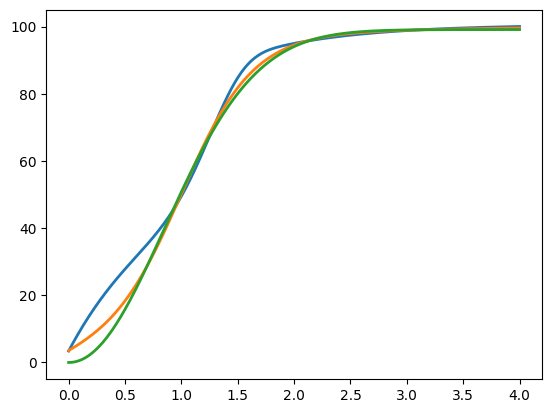

In [5]:
for res in results:
        if res.name == "Avrami":
            y_grid = avrami(t_grid, *res.popt)
        elif res.name == "Pasternack":
            y_grid = pasternack(t_grid, *res.popt)
        elif res.name == "Second-order (thesis form)":
            y_grid = second_order_thesis(t_grid, *res.popt)
        else:
            y_grid = second_order_shifted(t_grid, *res.popt)
        plt.plot(t_grid, y_grid, linewidth=2, label=f"{res.name}")

In [129]:
results[2]

FitResult(name='Avrami', popt=array([99.12746686,  0.71872356,  2.04878221]), pcov=array([[ 0.03771357,  0.00018242, -0.00837658],
       [ 0.00018242,  0.000653  , -0.00144585],
       [-0.00837658, -0.00144585,  0.00986789]]), yfit=array([ 0.        , 15.80654317, 50.81532042, 80.07923711, 94.06101553,
       98.2234961 , 99.01974775, 99.11892516, 99.12701752]), r2=0.9891727933580909, rmse=3.6023507802075225, mape=16.132796472986616, aic=29.068559283408202, bic=29.66023301541686)

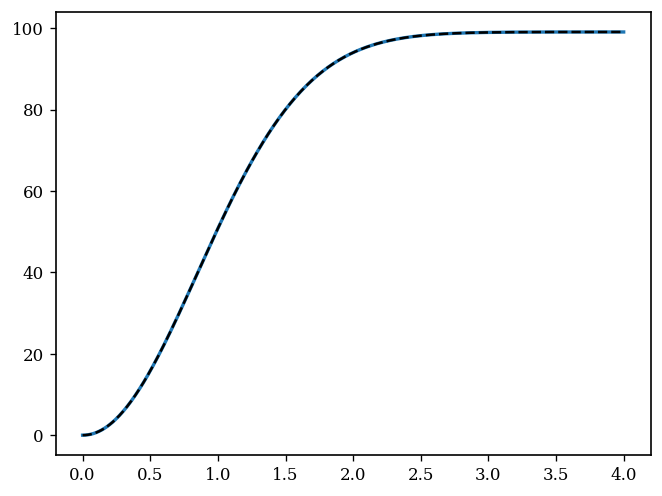

In [124]:
plt.plot(t_grid, y_grid, linewidth=2, label=f"{res.name}")
plt.plot(t_grid, avrami(t_grid, *results[2].popt), 'k--', label='Best fit (Avrami)')

In [118]:
results[2].name

'Avrami'

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
import sys
#sys.path.append(r'c:/Users/sebas/MalariaProject/src')
sys.path.append('/home/sgaviria/MalariaProject/src')

#from src import *
from model2D_v3 import Params2D, KMC2D, KMC2DVisualizer
#from src import KMCParams, LatticeSOS, KMC_BKL, Plotter, KMCParams_v4, LatticeSOS_v4, KMC_BKL_v4

# =========================
# ESTILO ACADÉMICO
# =========================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

In [8]:
archivo1 = r"/home/sgaviria/MalariaProject/notebooks/beta-hematina.txt"

data_txt = pd.read_csv(archivo1, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])

# **Resultados 2D**

In [9]:
from pathlib import Path
import sys
# Carpeta de salida para GIFs
root = Path.cwd().resolve()
#root = r'C:/Users/sebas/MalariaProject/notebooks'
out_dir = root / "results" / "modelos_gifs"
out_dir.mkdir(parents=True, exist_ok=True)

## **Isotrópico**

In [10]:
# Modelo 2D isotropico sin solvente
p2d_iso = Params2D(
    Ead=0.25, Ede=0.35, Eai=0.0, Eab=0.0, Eac=0.0,
    Jad_x=0.001, Jad_y=0.001,
    Jinc_x=0.01, Jinc_y=0.01,
    Jdes_x=0.04, Jdes_y=0.04,
    Jmove_x=0.0, Jmove_y=0.0,
    #solvent_ads_factor=#0.1,
    #solvent_des_factor=#0.1,
    #solvent_diff_factor=#0.1,
    #solvent_inc_factor=#0.1,
    Lx=80, Ly=80,
 )
 # Ejecuta el motor sin anisotropia y sin solvente
kmc2d_iso = KMC2D(p2d_iso, seed=1, n_seeds=53, use_anisotropy=False, use_solvent=False)

# Corre con snapshots para visualizacion
times_2d_iso, cover_2d_iso, snapshots_2d_iso = kmc2d_iso.run_until(
    tmax=4.0, snapshot_every=1.0, store_snapshots=True
 )
grid_2d_iso = snapshots_2d_iso[-1][1] if snapshots_2d_iso else kmc2d_iso.grid.copy()
final_t = float(times_2d_iso[-1]) if len(times_2d_iso) else 0.0
final_cover = float(cover_2d_iso[-1]) if len(cover_2d_iso) else 0.0
print("2D isotropico sin solvente:", final_t, final_cover)

0.0
2.4887791041425356e-07
6.593221728016014e-07
1.4998438206899523e-06
0.018824698671885323
0.04430380781500747
0.07734697686539475
0.10368116884999332
0.12685911394835758
0.155210648736392
0.16727479999529224
0.19299940726351553
0.21766721161253527
0.23798608160696055
0.25587321697117915
0.26856739334566426
0.2811007511386499
0.2982124631610679
0.3182932326538379
0.3439000127401568
0.356606081012481
0.367024032113808
0.3816884968646651
0.39556213695391584
0.4128989933832528
0.4235661921447189
0.43733740673437665
0.4515674387760551
0.46043190803889195
0.46794091363327583
0.48173105347915773
0.49816192165052947
0.5112266614137649
0.5260927124002355
0.5406160383076629
0.5559366629703097
0.5715236906964416
0.5872551948485947
0.6018641324619273
0.6161102202512516
0.6299356835341192
0.6479459508615287
0.6605805903153376
0.6703278396027197
0.6795850579254236
0.693367325849057
0.703712167933338
0.7179706298709394
0.728072073611377
0.7392599126356314
0.7502209963785447
0.763634833823478
0.777

In [106]:
times_2d_iso[10950]#*60

2.498440954307629

In [112]:
snapshots_2d_iso[109]

(2.4037642995874857,
 array([[2, 1, 2, ..., 2, 2, 1],
        [2, 2, 0, ..., 2, 2, 2],
        [2, 0, 2, ..., 1, 2, 1],
        ...,
        [1, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [1, 2, 2, ..., 1, 2, 1]], dtype=int8))

In [22]:
11272 / 113

99.75221238938053

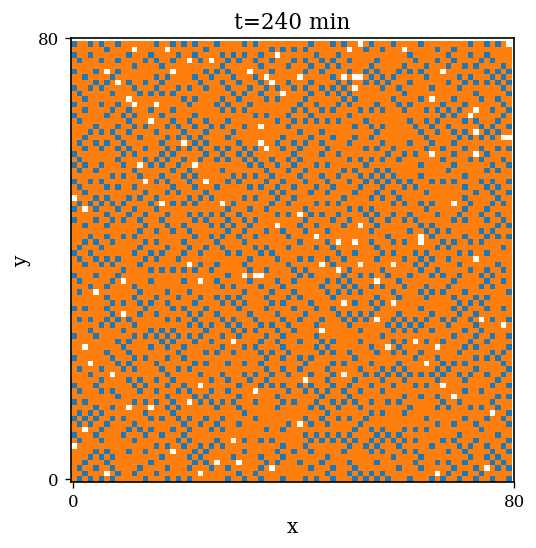

In [114]:
# Visualizacion 2D: ultimo snapshot y GIF
viz_2d_iso = KMC2DVisualizer()
if snapshots_2d_iso:
    viz_2d_iso.plot_snapshot(
        snapshots_2d_iso[-1],
        title="t={:.0f} min".format(times_2d_iso[-1]*60),
        show=True,
    )
    gif_path = out_dir / "2d_isotropico_sin_solvente_prueba_cc.gif"
#     try:
#         viz_2d_iso.save_gif(
#             snapshots_2d_iso,
#             out_path=str(gif_path),
#             fps=8,
#             dpi=120,
#         )
#         print(f"GIF guardado en: {gif_path}")
#     except Exception as exc:
#         print("No se pudo guardar el GIF:", exc)
# else:
#     print("No hay snapshots para visualizar.")

## **Anisotrópico**

In [95]:
# Modelo 2D anisotropico sin solvente
p2d_aniso = Params2D(
    Ead=0.25, Ede=0.35, Eai=0.0, Eab=0.0, Eac=0.0,
    Jad_x=0.05, Jad_y=0.001,
    Jinc_x=0.05, Jinc_y=0.001,
    Jdes_x=0.08, Jdes_y=0.004,
    Jmove_x=0.0, Jmove_y=0.0,
    #solvent_ads_factor=1.0,
    #solvent_des_factor=1.0,
    #solvent_diff_factor=1.0,
    #solvent_inc_factor=1.0,
    Lx=80, Ly=80,
 )
 # Ejecuta el motor con anisotropia marcada y sin solvente
kmc2d_aniso = KMC2D(p2d_aniso, seed=1, n_seeds=105, use_anisotropy=True, use_solvent=False)

# Corre con snapshots para visualizacion
times_2d_aniso, cover_2d_aniso, snapshots_2d_aniso = kmc2d_aniso.run_until(
    tmax=4.0, snapshot_every=1.0, store_snapshots=True
 )
grid_2d_aniso = snapshots_2d_aniso[-1][1] if snapshots_2d_aniso else kmc2d_aniso.grid.copy()
final_t = float(times_2d_aniso[-1]) if len(times_2d_aniso) else 0.0
final_cover = float(cover_2d_aniso[-1]) if len(cover_2d_aniso) else 0.0
print("2D anisotropico sin solvente:", final_t, final_cover)

0.0
1.3267638287525622e-07
2.776723233305122e-07
4.63744950892686e-07
7.786738809359155e-07
1.4406310736801647e-06
0.02588467672364609
0.06443726527596691
0.1281780178477414
0.16815095401890584
0.22387779310330938
0.25037491818334756
0.3021864709640155
0.3440295185145971
0.38731926227358776
0.41370236727031945
0.4508040572243336
0.4728844716289808
0.5124802796124963
0.5383191494340545
0.5585777963288793
0.5868406813369608
0.6113354757525905
0.6391692726120134
0.662215818394281
0.691294860874341
0.7271960901734095
0.7643731102051446
0.7918226916391155
0.8222342671344605
0.8486723727083026
0.872213385580689
0.9162255827953473
0.9367236007300539
0.9748070615572089
1.0007891529498518
1.0347434212378757
1.0651154530880653
1.0882301448418152
1.143652779954512
1.1744284587578835
1.211152505030716
1.2370895798006518
1.2765265709627176
1.3026073045541198
1.324557073183326
1.367583549617193
1.3990126203975108
1.4409257341216772
1.4649485859830786
1.5141000287410091
1.5728987448264469
1.605241799

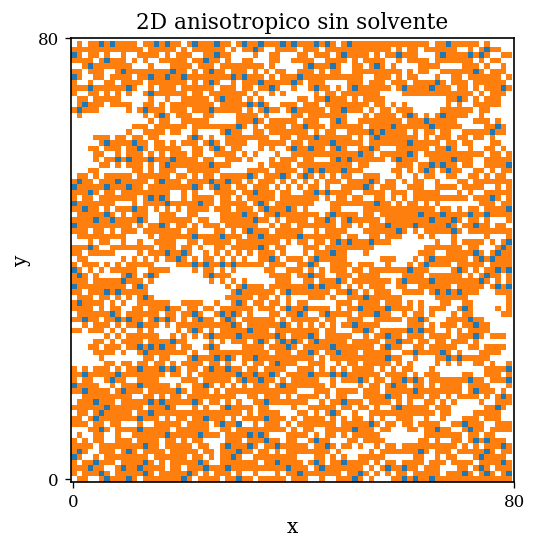

GIF guardado en: /home/sgaviria/MalariaProject/notebooks/results/modelos_gifs/2d_anisotropico_sin_solvente.gif


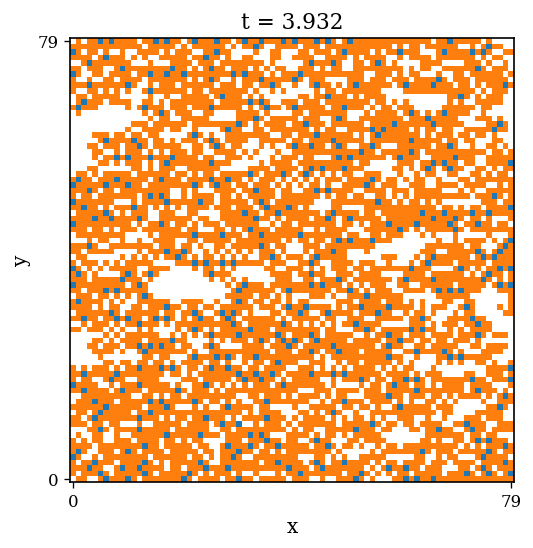

In [11]:
# Visualizacion 2D: ultimo snapshot y GIF
viz_2d_aniso = KMC2DVisualizer()
if snapshots_2d_aniso:
    viz_2d_aniso.plot_snapshot(
        snapshots_2d_aniso[-1],
        title="2D anisotropico sin solvente",
        show=True,
    )
    gif_path = out_dir / "2d_anisotropico_sin_solvente.gif"
    try:
        viz_2d_aniso.save_gif(
            snapshots_2d_aniso,
            out_path=str(gif_path),
            fps=8,
            dpi=120,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

Target 0.0 → Encontrado 0.000000 | Derecho: 0.008281
Target 0.0 → Encontrado 0.000000 | Derecho: 0.008281
Target 0.0 → Encontrado 0.000000 | Derecho: 0.008438
Target 0.0 → Encontrado 0.000000 | Derecho: 0.008594
Target 0.0 → Encontrado 0.000000 | Derecho: 0.008750
Target 0.0 → Encontrado 0.000000 | Derecho: 0.008750
Target 0.0 → Encontrado 0.000000 | Derecho: 0.008750
Target 0.0 → Encontrado 0.000000 | Derecho: 0.008906
Target 0.0 → Encontrado 0.000000 | Derecho: 0.009062
Target 0.0 → Encontrado 0.000000 | Derecho: 0.009062
Target 0.0 → Encontrado 0.000000 | Derecho: 0.009219
Target 0.0 → Encontrado 0.000000 | Derecho: 0.009375
Target 0.0 → Encontrado 0.000000 | Derecho: 0.009531
Target 0.0 → Encontrado 0.000000 | Derecho: 0.009687
Target 0.0 → Encontrado 0.000000 | Derecho: 0.009687
Target 0.0 → Encontrado 0.000000 | Derecho: 0.009844
Target 0.0 → Encontrado 0.000000 | Derecho: 0.009844
Target 0.0 → Encontrado 0.000000 | Derecho: 0.009844
Target 0.0 → Encontrado 0.000000 | Derecho: 0.

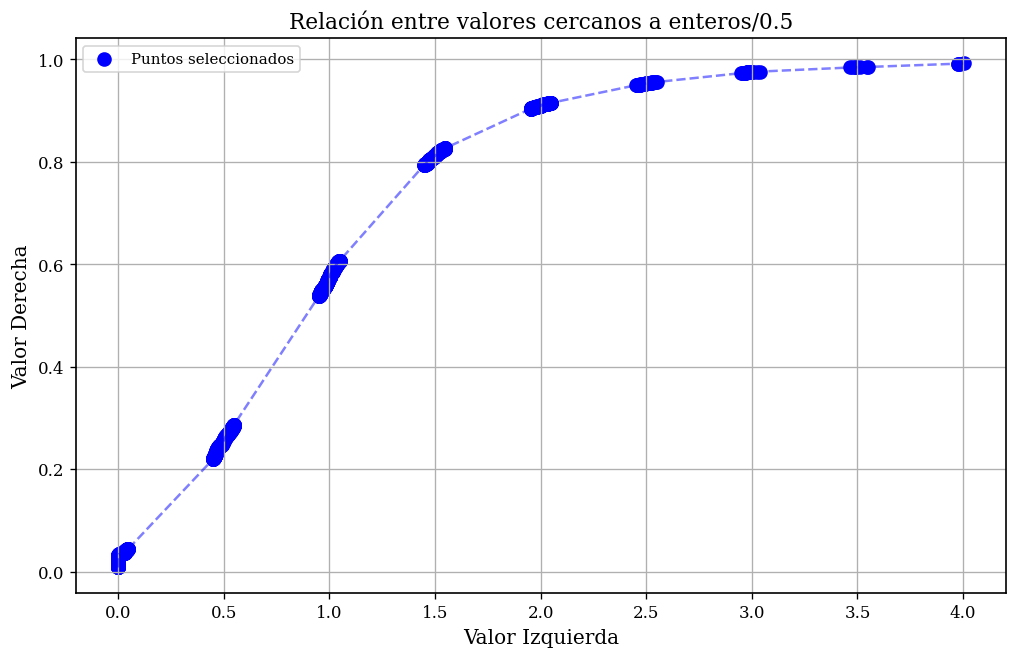

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Suponiendo que tu array se llama "data"
# data = np.array(...)  # tu array dtype=object

# Extraer columnas
left = times_2d_iso
right = cover_2d_iso

# Targets que quieres
targets = np.array([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])

tolerancia = 0.05   # ← Ajusta según tu precisión (0.01, 0.1, etc.)

# Lista para guardar los pares seleccionados
pares = []

for target in targets:
    # Encontrar los índices más cercanos al target
    diff = np.abs(left - target)
    mask = diff <= tolerancia
    
    if np.any(mask):
        idx = np.where(mask)[0]
        for i in idx:
            pares.append((left[i], right[i]))
            print(f"Target {target:.1f} → Encontrado {left[i]:.6f} | Derecho: {right[i]:.6f}")
    else:
        print(f"⚠️ No se encontró valor cercano a {target}")

# Convertir a arrays para graficar
if pares:
    left_sel, right_sel = zip(*pares)
    left_sel = np.array(left_sel)
    right_sel = np.array(right_sel)
    
    print(f"\nTotal de puntos seleccionados: {len(pares)}")
    
    # Graficar
    plt.figure(figsize=(10, 6))
    plt.scatter(left_sel, right_sel, color='blue', s=60, label='Puntos seleccionados')
    plt.plot(left_sel, right_sel, 'b--', alpha=0.5)
    
    plt.xlabel('Valor Izquierda')
    plt.ylabel('Valor Derecha')
    plt.title('Relación entre valores cercanos a enteros/0.5')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No se encontraron puntos")

In [122]:
results[0]

FitResult(name='Pasternack', popt=array([100.61500403,  41.80219555,  55.40327911,   0.22119172,
         1.14622102,   5.37631575]), pcov=array([[ 3.20815871e-01,  1.58686730e+00, -1.68740054e+00,
         4.76043096e-02, -6.68870499e-02, -4.03156603e-01],
       [ 1.58686730e+00,  1.75495970e+02, -1.85389323e+02,
         3.16085664e+00, -1.44685913e+00, -3.28350298e+01],
       [-1.68740054e+00, -1.85389323e+02,  2.10537692e+02,
        -3.25075986e+00,  1.62735517e+00,  3.39495797e+01],
       [ 4.76043096e-02,  3.16085664e+00, -3.25075986e+00,
         6.04177419e-02, -2.93133166e-02, -6.20573325e-01],
       [-6.68870499e-02, -1.44685913e+00,  1.62735517e+00,
        -2.93133166e-02,  2.29692270e-02,  2.87002769e-01],
       [-4.03156603e-01, -3.28350298e+01,  3.39495797e+01,
        -6.20573325e-01,  2.87002769e-01,  6.55868696e+00]]), yfit=array([  3.40952937,  27.80016549,  49.49877698,  84.7789811 ,
        95.0139179 ,  97.45969568,  98.83613869,  99.61213472,
       100.049

TypeError: avrami() takes 4 positional arguments but 7 were given

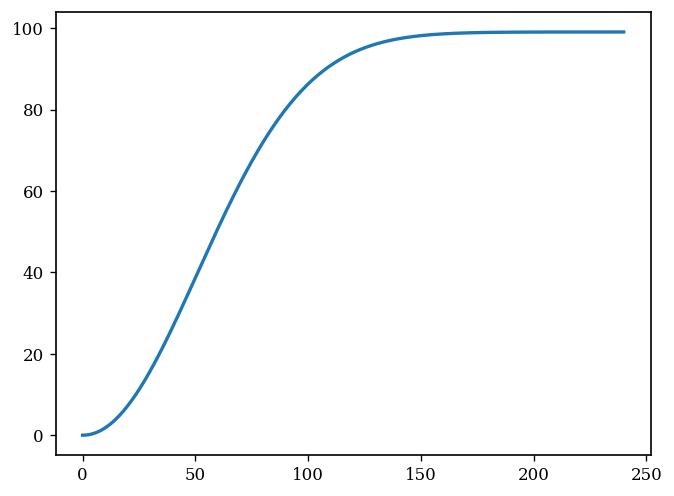

In [121]:
#plt.plot(t_grid, y_grid, linewidth=2, label=f"{res.name}")
plt.plot(t_grid*60, avrami(t_grid, *results[2].popt), linewidth=2, label='Modelo Avrami')
plt.plot(t_grid*60, avrami(t_grid, *results[0].popt), linewidth=2, label='Modelo Pasternack')
plt.plot(t_grid*60, avrami(t_grid, *results[1].popt), linewidth=2, label='Modelo de Segundo Orden')

plt.plot(times_2d_iso*60, cover_2d_iso*100, label="Modelo kMC", color='orange')
plt.plot(data_txt["Tiempo"]*60, data_txt["Porcentaje"], linestyle='--', color='black')
plt.errorbar(data_txt['Tiempo']*60,
            data_txt['Porcentaje'],
            yerr=data_txt['Error'],
            fmt="o",
            color='black',
            capsize=3,
            label="Datos experimentales",
            markersize=5,
            )
plt.legend()
plt.xlabel("Tiempo (min)")
plt.ylabel("Conversión (%)")
#plt.title("Comparación de conversión vs tiempo")
plt.grid()
plt.tight_layout()
plt.show()

## **Vis**

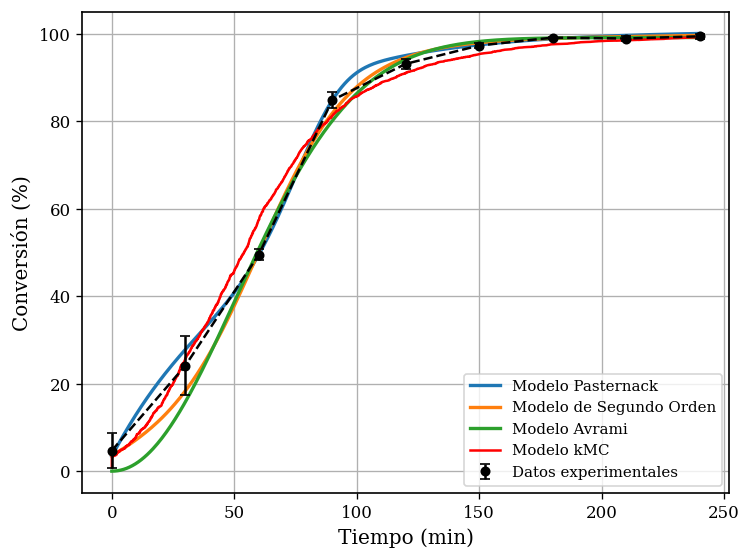

In [137]:
for res in results:
        if res.name == "Modelo Avrami":
            y_grid = avrami(t_grid, *res.popt)
            linestyle='-'
        elif res.name == "Modelo Pasternack":
            y_grid = pasternack(t_grid, *res.popt)
            linestyle='-'
        elif res.name == "Modelo de Segundo Orden":
            y_grid = second_order_thesis(t_grid, *res.popt)
            linestyle='-'
        else:
            y_grid = second_order_shifted(t_grid, *res.popt)
        
        plt.plot(t_grid*60, y_grid, linewidth=2, linestyle=linestyle, label=f"{res.name}")

plt.plot(times_2d_iso*60, cover_2d_iso*100, label="Modelo kMC", color='red')
#plt.plot(left_sel*60, right_sel*100, color='red', linestyle='-.', label='Puntos seleccionados')
#plt.plot(times_2d_aniso*60, cover_2d_aniso*100, label="Modelo kMC 2D anisotropico")
plt.plot(data_txt["Tiempo"]*60, data_txt["Porcentaje"], linestyle='--', color='black')
plt.errorbar(data_txt['Tiempo']*60,
            data_txt['Porcentaje'],
            yerr=data_txt['Error'],
            fmt="o",
            color='black',
            capsize=3,
            label="Datos experimentales",
            markersize=5,
            )
plt.legend()
plt.xlabel("Tiempo (min)")
plt.ylabel("Conversión (%)")
#plt.title("Comparación de conversión vs tiempo")
plt.grid()
plt.tight_layout()
plt.show()

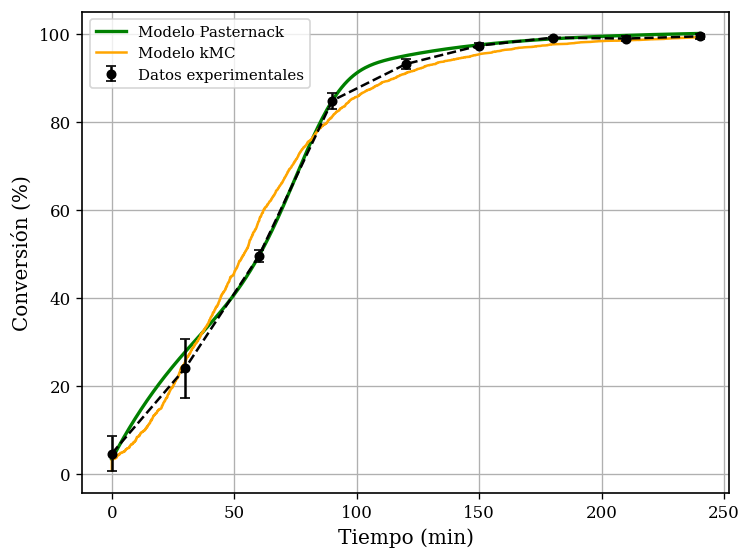

In [153]:
for res in results:
        #if res.name == "Avrami":
        #    y_grid = avrami(t_grid, *res.popt)
        if res.name == "Pasternack":
             y_grid = pasternack(t_grid, *res.popt)
        # #elif res.name == "Second-order (thesis form)":
        # #    y_grid = second_order_thesis(t_grid, *res.popt)
        # else:
        #     y_grid = second_order_shifted(t_grid, *res.popt)
plt.plot(t_grid*60, y_grid, linewidth=2, label=f"Modelo Pasternack", color='green')

plt.plot(times_2d_iso*60, cover_2d_iso*100, label="Modelo kMC", color='orange')
#plt.plot(left_sel*60, right_sel*100, color='red', linestyle='-.', label='Puntos seleccionados')
#plt.plot(times_2d_aniso*60, cover_2d_aniso*100, label="Modelo kMC 2D anisotropico")
plt.plot(data_txt["Tiempo"]*60, data_txt["Porcentaje"], linestyle='--', color='black')
plt.errorbar(data_txt['Tiempo']*60,
            data_txt['Porcentaje'],
            yerr=data_txt['Error'],
            fmt="o",
            color='black',
            capsize=3,
            label="Datos experimentales",
            markersize=5,
            )
plt.legend()
plt.xlabel("Tiempo (min)")
plt.ylabel("Conversión (%)")
#plt.title("Comparación de conversión vs tiempo")
plt.grid()
plt.tight_layout()
plt.show()

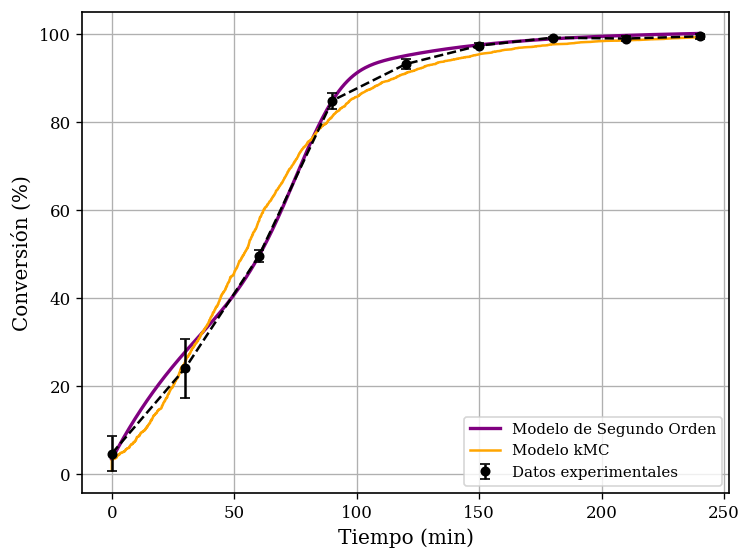

In [154]:
for res in results:
        #if res.name == "Avrami":
        #    y_grid = avrami(t_grid, *res.popt)
        if res.name == "Pasternack":
             y_grid = pasternack(t_grid, *res.popt)
        # #elif res.name == "Second-order (thesis form)":
        # #    y_grid = second_order_thesis(t_grid, *res.popt)
        # else:
        #     y_grid = second_order_shifted(t_grid, *res.popt)
plt.plot(t_grid*60, y_grid, linewidth=2, label=f"Modelo de Segundo Orden", color='purple')

plt.plot(times_2d_iso*60, cover_2d_iso*100, label="Modelo kMC", color='orange')
#plt.plot(left_sel*60, right_sel*100, color='red', linestyle='-.', label='Puntos seleccionados')
#plt.plot(times_2d_aniso*60, cover_2d_aniso*100, label="Modelo kMC 2D anisotropico")
plt.plot(data_txt["Tiempo"]*60, data_txt["Porcentaje"], linestyle='--', color='black')
plt.errorbar(data_txt['Tiempo']*60,
            data_txt['Porcentaje'],
            yerr=data_txt['Error'],
            fmt="o",
            color='black',
            capsize=3,
            label="Datos experimentales",
            markersize=5,
            )
plt.legend()
plt.xlabel("Tiempo (min)")
plt.ylabel("Conversión (%)")
#plt.title("Comparación de conversión vs tiempo")
plt.grid()
plt.tight_layout()
plt.show()

# **Resultados 3D**

## **Isotrópico**

In [30]:
conv80_iso_03 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso_3/size_80x80_sigma_0.3_seed_123/conversion_history.csv')
conv80_iso_04 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_0.4_seed_123/conversion_history.csv')
conv80_iso_05 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_0.5_seed_123/conversion_history.csv')
conv80_iso_06 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_0.6_seed_123/conversion_history.csv')
conv80_iso_07 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_0.7_seed_123/conversion_history.csv')
conv80_iso_08 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso_4/size_80x80_sigma_0.8_seed_123/conversion_history.csv')
conv80_iso_09 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso_4/size_80x80_sigma_0.9_seed_123/conversion_history.csv')
conv80_iso_1 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso_2/size_80x80_sigma_1_seed_123/conversion_history.csv')
conv80_iso_3 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso_2/size_80x80_sigma_3_seed_123/conversion_history.csv')
conv80_iso_5 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso_2/size_80x80_sigma_5_seed_123/conversion_history.csv')
conv80_iso_7 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso_2/size_80x80_sigma_7_seed_123/conversion_history.csv')


Buscando valores cercanos...

⚠️ Target 0.0 → Mejor aproximación: time = 0.006285 | conversion = 0.000000
⚠️ Target 0.0 → Mejor aproximación: time = 0.002558 | conversion = 0.000000
⚠️ Target 0.0 → Mejor aproximación: time = 0.002558 | conversion = 0.000000
⚠️ Target 0.0 → Mejor aproximación: time = 0.002388 | conversion = 0.000000
⚠️ Target 0.0 → Mejor aproximación: time = 0.002239 | conversion = 0.000000
⚠️ Target 0.0 → Mejor aproximación: time = 0.002107 | conversion = 0.000000
Target 0.0 → time = 0.000000 | conversion = 0.000000
Target 0.0 → time = 0.000000 | conversion = 0.000000
Target 0.0 → time = 0.000000 | conversion = 0.000000
Target 0.0 → time = 0.000001 | conversion = 0.000000
Target 0.0 → time = 0.000001 | conversion = 0.000000
Target 0.0 → time = 0.000001 | conversion = 0.000000
Target 0.0 → time = 0.000001 | conversion = 0.000000
Target 0.0 → time = 0.000002 | conversion = 0.000000
Target 0.0 → time = 0.000002 | conversion = 0.000000
Target 0.0 → time = 0.000002 | conver

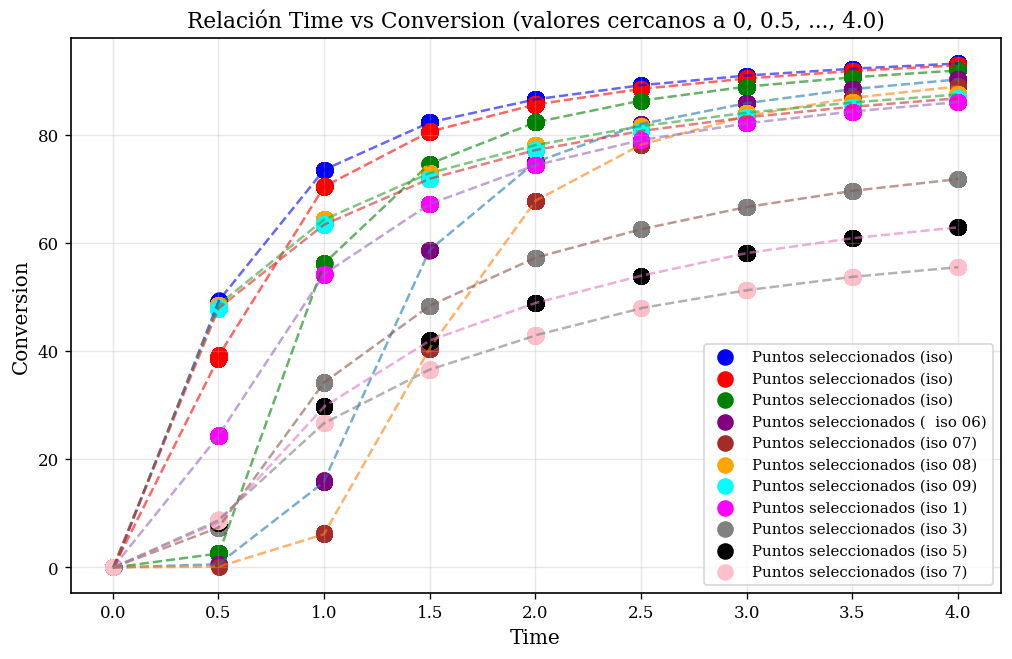

In [32]:
# Suponiendo que tu DataFrame se llama "df"
# df = pd.read_csv(...) o como lo hayas cargado

# ==================== CONFIGURACIÓN ====================
targets = np.array([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])
tolerancia = 2e-3          # ← Ajusta según necesites (0.01, 0.1, etc.)


# Extraer columnas
time_iso_03 = conv80_iso_03['time'].values
conversion_iso_03 = conv80_iso_03['conversion'].values

time_iso_04 = conv80_iso_04['time'].values
conversion_iso_04 = conv80_iso_04['conversion'].values

time_iso_05 = conv80_iso_05['time'].values
conversion_iso_05 = conv80_iso_05['conversion'].values

time_iso_06 = conv80_iso_06['time'].values
conversion_iso_06 = conv80_iso_06['conversion'].values

time_iso_07 = conv80_iso_07['time'].values
conversion_iso_07 = conv80_iso_07['conversion'].values

time_iso_08 = conv80_iso_08['time'].values
conversion_iso_08 = conv80_iso_08['conversion'].values

time_iso_09 = conv80_iso_09['time'].values
conversion_iso_09 = conv80_iso_09['conversion'].values

time_iso_1 = conv80_iso_1['time'].values
conversion_iso_1 = conv80_iso_1['conversion'].values

time_iso_3 = conv80_iso_3['time'].values
conversion_iso_3 = conv80_iso_3['conversion'].values

time_iso_5 = conv80_iso_5['time'].values
conversion_iso_5 = conv80_iso_5['conversion'].values

time_iso_7 = conv80_iso_7['time'].values
conversion_iso_7 = conv80_iso_7['conversion'].values

# Lista para guardar los pares seleccionados

pares_iso_03 = []
pares_iso_04 = []
pares_iso_05 = []
pares_iso_06 = []
pares_iso_07 = []
pares_iso_08 = []
pares_iso_09 = []
pares_iso_1 = []
pares_iso_3 = []
pares_iso_5 = []
pares_iso_7 = []

print("Buscando valores cercanos...\n")

for target in targets:
    # Calcular diferencia
    diff_iso_03 = np.abs(time_iso_03 - target)
    mask_iso_03 = diff_iso_03 <= tolerancia

    diff_iso_04 = np.abs(time_iso_04 - target)
    mask_iso_04 = diff_iso_04 <= tolerancia
    
    diff_iso_05 = np.abs(time_iso_05 - target)
    mask_iso_05 = diff_iso_05 <= tolerancia

    diff_iso_06 = np.abs(time_iso_06 - target)
    mask_iso_06 = diff_iso_06 <= tolerancia

    diff_iso_07 = np.abs(time_iso_07 - target)
    mask_iso_07 = diff_iso_07 <= tolerancia

    diff_iso_08 = np.abs(time_iso_08 - target)
    mask_iso_08 = diff_iso_08 <= tolerancia

    diff_iso_09 = np.abs(time_iso_09 - target)
    mask_iso_09 = diff_iso_09 <= tolerancia

    diff_iso_1 = np.abs(time_iso_1 - target)
    mask_iso_1 = diff_iso_1 <= tolerancia

    diff_iso_3 = np.abs(time_iso_3 - target)
    mask_iso_3 = diff_iso_3 <= tolerancia

    diff_iso_5 = np.abs(time_iso_5 - target)
    mask_iso_5 = diff_iso_5 <= tolerancia

    diff_iso_7 = np.abs(time_iso_7 - target)
    mask_iso_7 = diff_iso_7 <= tolerancia

    if np.any(mask_iso_03):
        indices = np.where(mask_iso_03)[0]
        for i in indices:
            pares_iso_03.append((time_iso_03[i], conversion_iso_03[i]))
            print(f"Target {target:.1f} → time = {time_iso_03[i]:.6f} | conversion = {conversion_iso_03[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_03)
        pares_iso_03.append((time_iso_03[idx], conversion_iso_03[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_03[idx]:.6f} | conversion = {conversion_iso_03[idx]:.6f}")

    if np.any(mask_iso_04):
        indices = np.where(mask_iso_04)[0]
        for i in indices:
            pares_iso_04.append((time_iso_04[i], conversion_iso_04[i]))
            print(f"Target {target:.1f} → time = {time_iso_04[i]:.6f} | conversion = {conversion_iso_04[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_04)
        pares_iso_04.append((time_iso_04[idx], conversion_iso_04[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_04[idx]:.6f} | conversion = {conversion_iso_04[idx]:.6f}")

    if np.any(mask_iso_04):
        indices = np.where(mask_iso_04)[0]
        for i in indices:
            pares_iso_04.append((time_iso_04[i], conversion_iso_04[i]))
            print(f"Target {target:.1f} → time = {time_iso_04[i]:.6f} | conversion = {conversion_iso_04[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_04)
        pares_iso_04.append((time_iso_04[idx], conversion_iso_04[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_04[idx]:.6f} | conversion = {conversion_iso_04[idx]:.6f}")

    if np.any(mask_iso_05):
        indices = np.where(mask_iso_05)[0]
        for i in indices:
            pares_iso_05.append((time_iso_05[i], conversion_iso_05[i]))
            print(f"Target {target:.1f} → time = {time_iso_05[i]:.6f} | conversion = {conversion_iso_05[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_05)
        pares_iso_05.append((time_iso_05[idx], conversion_iso_05[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_05[idx]:.6f} | conversion = {conversion_iso_05[idx]:.6f}")

    if np.any(mask_iso_06):
        indices = np.where(mask_iso_06)[0]
        for i in indices:
            pares_iso_06.append((time_iso_06[i], conversion_iso_06[i]))
            print(f"Target {target:.1f} → time = {time_iso_06[i]:.6f} | conversion = {conversion_iso_06[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_06)
        pares_iso_06.append((time_iso_06[idx], conversion_iso_06[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_06[idx]:.6f} | conversion = {conversion_iso_06[idx]:.6f}")

    if np.any(mask_iso_07):
        indices = np.where(mask_iso_07)[0]
        for i in indices:
            pares_iso_07.append((time_iso_07[i], conversion_iso_07[i]))
            print(f"Target {target:.1f} → time = {time_iso_07[i]:.6f} | conversion = {conversion_iso_07[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_07)
        pares_iso_07.append((time_iso_07[idx], conversion_iso_07[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_07[idx]:.6f} | conversion = {conversion_iso_07[idx]:.6f}")

    if np.any(mask_iso_08):
        indices = np.where(mask_iso_08)[0]
        for i in indices:
            pares_iso_08.append((time_iso_08[i], conversion_iso_08[i]))
            print(f"Target {target:.1f} → time = {time_iso_08[i]:.6f} | conversion = {conversion_iso_08[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_08)
        pares_iso_08.append((time_iso_08[idx], conversion_iso_08[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_08[idx]:.6f} | conversion = {conversion_iso_08[idx]:.6f}")

    if np.any(mask_iso_09):
        indices = np.where(mask_iso_09)[0]
        for i in indices:
            pares_iso_09.append((time_iso_09[i], conversion_iso_09[i]))
            print(f"Target {target:.1f} → time = {time_iso_09[i]:.6f} | conversion = {conversion_iso_09[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_09)
        pares_iso_09.append((time_iso_09[idx], conversion_iso_09[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_09[idx]:.6f} | conversion = {conversion_iso_09[idx]:.6f}")

    if np.any(mask_iso_1):
        indices = np.where(mask_iso_1)[0]
        for i in indices:
            pares_iso_1.append((time_iso_1[i], conversion_iso_1[i]))
            print(f"Target {target:.1f} → time = {time_iso_1[i]:.6f} | conversion = {conversion_iso_1[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_1)
        pares_iso_1.append((time_iso_1[idx], conversion_iso_1[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_1[idx]:.6f} | conversion = {conversion_iso_1[idx]:.6f}")

    if np.any(mask_iso_3):
        indices = np.where(mask_iso_3)[0]
        for i in indices:
            pares_iso_3.append((time_iso_3[i], conversion_iso_3[i]))
            print(f"Target {target:.1f} → time = {time_iso_3[i]:.6f} | conversion = {conversion_iso_3[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_3)
        pares_iso_3.append((time_iso_3[idx], conversion_iso_3[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_3[idx]:.6f} | conversion = {conversion_iso_3[idx]:.6f}")

    if np.any(mask_iso_5):
        indices = np.where(mask_iso_5)[0]
        for i in indices:
            pares_iso_5.append((time_iso_5[i], conversion_iso_5[i]))
            print(f"Target {target:.1f} → time = {time_iso_5[i]:.6f} | conversion = {conversion_iso_5[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_5)
        pares_iso_5.append((time_iso_5[idx], conversion_iso_5[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_5[idx]:.6f} | conversion = {conversion_iso_5[idx]:.6f}")

    if np.any(mask_iso_7):
        indices = np.where(mask_iso_7)[0]
        for i in indices:
            pares_iso_7.append((time_iso_7[i], conversion_iso_7[i]))
            print(f"Target {target:.1f} → time = {time_iso_7[i]:.6f} | conversion = {conversion_iso_7[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso_7)
        pares_iso_7.append((time_iso_7[idx], conversion_iso_7[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso_7[idx]:.6f} | conversion = {conversion_iso_7[idx]:.6f}")



# Convertir a arrays
if pares_iso_03:
    times_sel_iso_03, conv_sel_iso_03 = zip(*pares_iso_03)
    times_sel_iso_03 = np.array(times_sel_iso_03)
    conv_sel_iso_03 = np.array(conv_sel_iso_03)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso_03)}")

if pares_iso_04:
    times_sel_iso_04, conv_sel_iso_04 = zip(*pares_iso_04)
    times_sel_iso_04 = np.array(times_sel_iso_04)
    conv_sel_iso_04 = np.array(conv_sel_iso_04)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso_04)}")

if pares_iso_05:
    times_sel_iso_05, conv_sel_iso_05 = zip(*pares_iso_05)
    times_sel_iso_05 = np.array(times_sel_iso_05)
    conv_sel_iso_05 = np.array(conv_sel_iso_05)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso_05)}")

if pares_iso_06:
    times_sel_iso_06, conv_sel_iso_06 = zip(*pares_iso_06)
    times_sel_iso_06 = np.array(times_sel_iso_06)
    conv_sel_iso_06 = np.array(conv_sel_iso_06)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso_06)}")

if pares_iso_07:
    times_sel_iso_07, conv_sel_iso_07 = zip(*pares_iso_07)
    times_sel_iso_07 = np.array(times_sel_iso_07)
    conv_sel_iso_07 = np.array(conv_sel_iso_07)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso_07)}")

if pares_iso_08:
    times_sel_iso_08, conv_sel_iso_08 = zip(*pares_iso_08)
    times_sel_iso_08 = np.array(times_sel_iso_08)
    conv_sel_iso_08 = np.array(conv_sel_iso_08)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso_08)}")

if pares_iso_09:
    times_sel_iso_09, conv_sel_iso_09 = zip(*pares_iso_09)
    times_sel_iso_09 = np.array(times_sel_iso_09)
    conv_sel_iso_09 = np.array(conv_sel_iso_09)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso_09)}")

if pares_iso_1:
    times_sel_iso_1, conv_sel_iso_1 = zip(*pares_iso_1)
    times_sel_iso_1 = np.array(times_sel_iso_1)
    conv_sel_iso_1 = np.array(conv_sel_iso_1)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso_1)}")

if pares_iso_3:
    times_sel_iso_3, conv_sel_iso_3 = zip(*pares_iso_3)
    times_sel_iso_3 = np.array(times_sel_iso_3)
    conv_sel_iso_3 = np.array(conv_sel_iso_3)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso_3)}")

if pares_iso_5:
    times_sel_iso_5, conv_sel_iso_5 = zip(*pares_iso_5)
    times_sel_iso_5 = np.array(times_sel_iso_5)
    conv_sel_iso_5 = np.array(conv_sel_iso_5)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso_5)}")

if pares_iso_7:
    times_sel_iso_7, conv_sel_iso_7 = zip(*pares_iso_7)
    times_sel_iso_7 = np.array(times_sel_iso_7)
    conv_sel_iso_7 = np.array(conv_sel_iso_7)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso_7)}")

    # ==================== GRÁFICO ====================
    plt.figure(figsize=(10, 6))
    plt.scatter(times_sel_iso_03, conv_sel_iso_03, color='blue', s=80, label='Puntos seleccionados (iso)')
    plt.plot(times_sel_iso_03, conv_sel_iso_03, 'b--', alpha=0.6)
    plt.scatter(times_sel_iso_04, conv_sel_iso_04, color='red', s=80, label='Puntos seleccionados (iso)')
    plt.plot(times_sel_iso_04, conv_sel_iso_04, 'r--', alpha=0.6)
    plt.scatter(times_sel_iso_05, conv_sel_iso_05, color='green', s=80, label='Puntos seleccionados (iso)')
    plt.plot(times_sel_iso_05, conv_sel_iso_05, 'g--', alpha=0.6)
    plt.scatter(times_sel_iso_06, conv_sel_iso_06, color='purple', s=80, label='Puntos seleccionados (  iso 06)')
    plt.plot(times_sel_iso_06, conv_sel_iso_06, '--', alpha=0.6)
    plt.scatter(times_sel_iso_07, conv_sel_iso_07, color='brown', s=80, label='Puntos seleccionados (iso 07)')
    plt.plot(times_sel_iso_07, conv_sel_iso_07, '--', alpha=0.6)
    plt.scatter(times_sel_iso_08, conv_sel_iso_08, color='orange', s=80, label='Puntos seleccionados (iso 08)')
    plt.plot(times_sel_iso_08, conv_sel_iso_08, '--', alpha=0.6)
    plt.scatter(times_sel_iso_09, conv_sel_iso_09, color='cyan', s=80, label='Puntos seleccionados (iso 09)')
    plt.plot(times_sel_iso_09, conv_sel_iso_09, '--', alpha=0.6)
    plt.scatter(times_sel_iso_1, conv_sel_iso_1, color='magenta', s=80, label='Puntos seleccionados (iso 1)')
    plt.plot(times_sel_iso_1, conv_sel_iso_1, '--', alpha=0.6)
    plt.scatter(times_sel_iso_3, conv_sel_iso_3, color='gray', s=80, label='Puntos seleccionados (iso 3)')
    plt.plot(times_sel_iso_3, conv_sel_iso_3, '--', alpha=0.6)
    plt.scatter(times_sel_iso_5, conv_sel_iso_5, color='black', s=80, label='Puntos seleccionados (iso 5)')
    plt.plot(times_sel_iso_5, conv_sel_iso_5, '--', alpha=0.6)
    plt.scatter(times_sel_iso_7, conv_sel_iso_7, color='pink', s=80, label='Puntos seleccionados (iso 7)')
    plt.plot(times_sel_iso_7, conv_sel_iso_7, '--', alpha=0.6)

    plt.xlabel('Time')
    plt.ylabel('Conversion')
    plt.title('Relación Time vs Conversion (valores cercanos a 0, 0.5, ..., 4.0)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

#     # Mostrar tabla de resultados
#     resultado = pd.DataFrame({
#         'target': targets,
#         'time': times_sel_iso,
#         'conversion': conv_sel_iso
#     })
#     print("\nTabla resumen:")
#     print(resultado)
# else:
#     print("No se encontraron puntos")

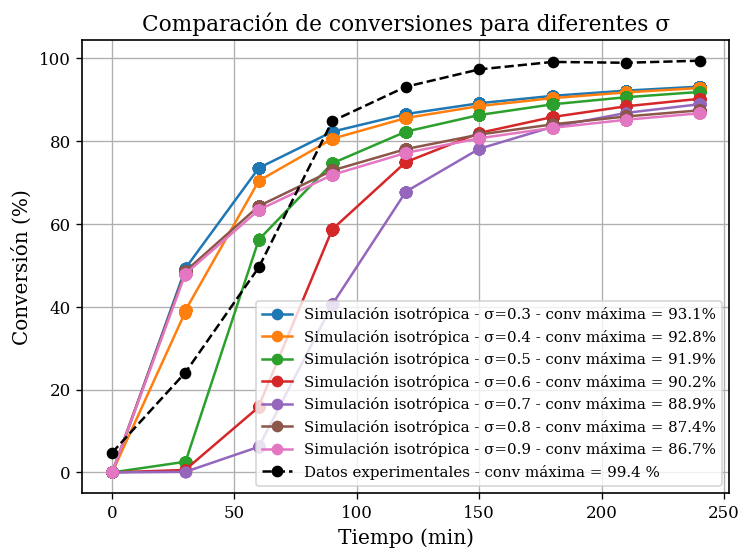

In [50]:
plt.plot(times_sel_iso_03*60, conv_sel_iso_03, label=f'Simulación isotrópica - σ=0.3 - conv máxima = {conv_sel_iso_03[-1]:.1f}%', linestyle='-', marker='o')#, color='red')
plt.plot(times_sel_iso_04*60, conv_sel_iso_04, label=f'Simulación isotrópica - σ=0.4 - conv máxima = {conv_sel_iso_04[-1]:.1f}%', linestyle='-', marker='o')#, color='blue')
plt.plot(times_sel_iso_05*60, conv_sel_iso_05, label=f'Simulación isotrópica - σ=0.5 - conv máxima = {conv_sel_iso_05[-1]:.1f}%', linestyle='-', marker='o')#, color='green')
plt.plot(times_sel_iso_06*60, conv_sel_iso_06, label=f'Simulación isotrópica - σ=0.6 - conv máxima = {conv_sel_iso_06[-1]:.1f}%', linestyle='-', marker='o')#, color='purple')
plt.plot(times_sel_iso_07*60, conv_sel_iso_07, label=f'Simulación isotrópica - σ=0.7 - conv máxima = {conv_sel_iso_07[-1]:.1f}%', linestyle='-', marker='o')#, color='brown')
plt.plot(times_sel_iso_08*60, conv_sel_iso_08, label=f'Simulación isotrópica - σ=0.8 - conv máxima = {conv_sel_iso_08[-1]:.1f}%', linestyle='-', marker='o')#, color='orange')
plt.plot(times_sel_iso_09*60, conv_sel_iso_09, label=f'Simulación isotrópica - σ=0.9 - conv máxima = {conv_sel_iso_09[-1]:.1f}%', linestyle='-', marker='o')#, color='cyan')
plt.plot(data_txt['Tiempo']*60, data_txt['Porcentaje'], label='Datos experimentales - conv máxima = 99.4 %', linestyle='--', marker='o', color='black')
plt.xlabel('Tiempo (min)')
plt.ylabel('Conversión (%)')
plt.title('Comparación de conversiones para diferentes σ')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

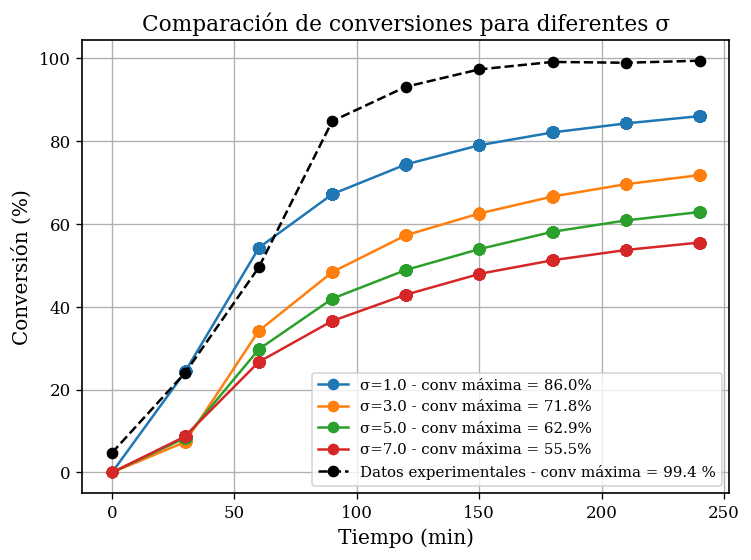

In [48]:
plt.plot(times_sel_iso_1*60, conv_sel_iso_1, label=f'σ=1.0 - conv máxima = {conv_sel_iso_1[-1]:.1f}%', linestyle='-', marker='o')#, color='magenta')
plt.plot(times_sel_iso_3*60, conv_sel_iso_3, label=f'σ=3.0 - conv máxima = {conv_sel_iso_3[-1]:.1f}%', linestyle='-', marker='o')#, color='gray')
plt.plot(times_sel_iso_5*60, conv_sel_iso_5, label=f'σ=5.0 - conv máxima = {conv_sel_iso_5[-1]:.1f}%', linestyle='-', marker='o')#, color='black')
plt.plot(times_sel_iso_7*60, conv_sel_iso_7, label=f'σ=7.0 - conv máxima = {conv_sel_iso_7[-1]:.1f}%', linestyle='-', marker='o')#, color='pink')
plt.plot(data_txt['Tiempo']*60, data_txt['Porcentaje'], label='Datos experimentales - conv máxima = 99.4 %', linestyle='--', marker='o', color='black')
plt.xlabel('Tiempo (min)')
plt.ylabel('Conversión (%)')
plt.title('Comparación de conversiones para diferentes σ')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

# **Anisotrópico**

In [ ]:
import pandas as pd

conv80_iso = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso_4/size_80x80_sigma_0.8_seed_123/conversion_history.csv')
conv80_aniso_03 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_aniso_3/size_80x80_sigma_0.3_seed_123/conversion_history.csv')
conv80_aniso_04 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_aniso_3/size_80x80_sigma_0.4_seed_123/conversion_history.csv')
conv80_aniso_05 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_aniso_3/size_80x80_sigma_0.5_seed_123/conversion_history.csv')
conv80_aniso_06 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_aniso_3/size_80x80_sigma_0.6_seed_123/conversion_history.csv')
conv80_aniso_07 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_aniso_3/size_80x80_sigma_0.7_seed_123/conversion_history.csv')

# **Concentración dinámica**

In [139]:
from src import *

In [140]:
params1 = KMCParams(
    T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT=1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta=1.7789686274068774,
    V=0.9943756704678864, #0.789,
    C_eq=6.66285823642452,#17.856385685984442, #171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

In [141]:
times = np.arange(0, 4.5, 0.5)

In [142]:
def func(size, N, t_s, n_s):
    
    L = LatticeSOS(size=size, seed=25)
    L.initialize("flat")

    kmc = KMC_BKL(L, params1, N_bulk0=N, rng_seed=123, time_scale=t_s, n_seeds=n_s)
    #kmc1 = KMC_BKL(L, params1, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)
    #kmc2 = KMC_BKL(L, params2, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)

    t0 = time.perf_counter()
    snaps = kmc.run(t_end=times[-1], snapshot_times=times)
    #snaps1 = kmc1.run(t_end=times[-1], snapshot_times=times)
    #snaps2 = kmc2.run(t_end=times[-1], snapshot_times=times)
    t1 = time.perf_counter()
    tiempo = t1 - t0

    print(f"\nTiempo de ejecución para tamaño {L.size}: {(tiempo)/60:.3f} minutos")

    return kmc, snaps


###### BUENO ######

#size: 30, t_s: 300, n_seeds: 100, N:2000
#size: 40, t_s: 600, n_seeds: 100, N:2000
#size: 70, t_s: 1100, n_seeds: 100, N:3000

In [143]:
kmc_1, snaps_1 = func(size=(70, 70), N=3000, t_s=1200, n_s=100)
kmc_3, snaps_3 = func(size=(70, 70), N=2000, t_s=2200, n_s=90)


Tiempo de ejecución para tamaño (70, 70): 3.205 minutos

Tiempo de ejecución para tamaño (70, 70): 1.804 minutos


In [145]:
times_1 = [t for t, _, _ in snaps_1]
conversions_1 = [conv for _, _, conv in snaps_1]

times_3 = [t for t, _, _ in snaps_3]
conversions_3 = [conv for _, _, conv in snaps_3]

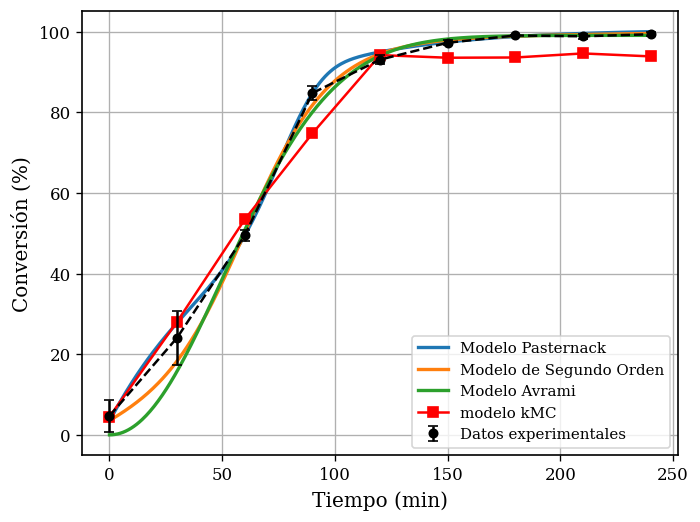

In [146]:
#plt.plot(times_1, conversions_1, linestyle='-', color='blue', label = 'simulación (70x70)-1')
#plt.plot(times_2, conversions_2, linestyle='-', color='red', label = 'simulación (40x40)')
for res in results:
        if res.name == "Modelo Avrami":
            y_grid = avrami(t_grid, *res.popt)
        elif res.name == "Modelo Pasternack":
            y_grid = pasternack(t_grid, *res.popt)
        elif res.name == "Modelo de Segundo Orden":
            y_grid = second_order_thesis(t_grid, *res.popt)
        else:
            y_grid = second_order_shifted(t_grid, *res.popt)
        
        plt.plot(t_grid*60, y_grid, linewidth=2, label=f"{res.name}")

plt.plot(np.array(times_3)*60, conversions_3, linestyle='-', color='red', marker='s', label = 'modelo kMC')
plt.plot(data_txt["Tiempo"]*60, data_txt["Porcentaje"], linestyle='--', color='black')
plt.errorbar(data_txt['Tiempo']*60,
            data_txt['Porcentaje'],
            yerr=data_txt['Error'],
            fmt="o",
            color='black',
            capsize=3,
            label="Datos experimentales",
            markersize=5,
            )

plt.xlabel("Tiempo (min)")
plt.ylabel("Conversión (%)")
#plt.title("Conversión vs Tiempo - kMC isotrópico 3D")
plt.legend()
plt.grid()
plt.show()

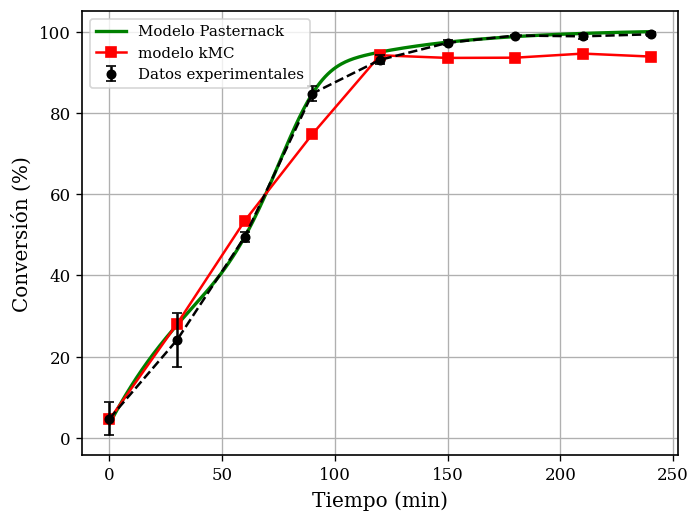

In [146]:
#plt.plot(times_1, conversions_1, linestyle='-', color='blue', label = 'simulación (70x70)-1')
#plt.plot(times_2, conversions_2, linestyle='-', color='red', label = 'simulación (40x40)')
for res in results:
        #if res.name == "Avrami":
        #    y_grid = avrami(t_grid, *res.popt)
        if res.name == "Pasternack":
              y_grid = pasternack(t_grid, *res.popt)
        # #elif res.name == "Second-order (thesis form)":
        # #    y_grid = second_order_thesis(t_grid, *res.popt)
        # else:
        #     y_grid = second_order_shifted(t_grid, *res.popt)
plt.plot(t_grid*60, y_grid, linewidth=2, label="Modelo Pasternack", color='green')

plt.plot(np.array(times_3)*60, conversions_3, linestyle='-', color='red', marker='s', label = 'modelo kMC')
plt.plot(data_txt["Tiempo"]*60, data_txt["Porcentaje"], linestyle='--', color='black')
plt.errorbar(data_txt['Tiempo']*60,
            data_txt['Porcentaje'],
            yerr=data_txt['Error'],
            fmt="o",
            color='black',
            capsize=3,
            label="Datos experimentales",
            markersize=5,
            )

plt.xlabel("Tiempo (min)")
plt.ylabel("Conversión (%)")
#plt.title("Conversión vs Tiempo - kMC isotrópico 3D")
plt.legend()
plt.grid()
plt.show()

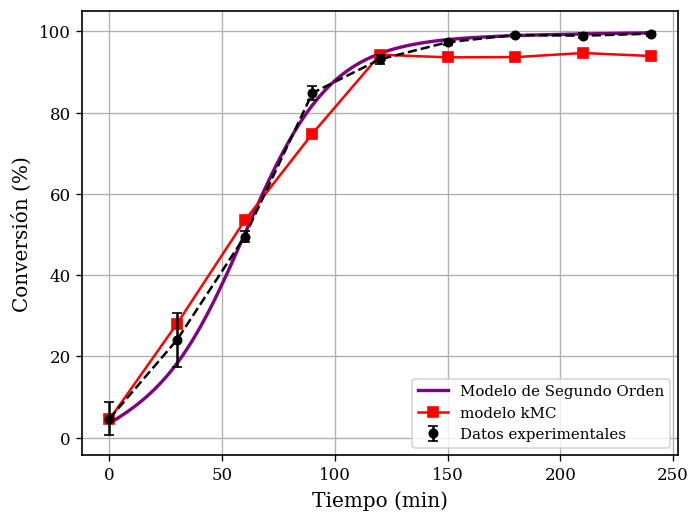

In [147]:
#plt.plot(times_1, conversions_1, linestyle='-', color='blue', label = 'simulación (70x70)-1')
#plt.plot(times_2, conversions_2, linestyle='-', color='red', label = 'simulación (40x40)')
for res in results:
        #if res.name == "Avrami":
        #    y_grid = avrami(t_grid, *res.popt)
        # elif res.name == "Pasternack":
        #     y_grid = pasternack(t_grid, *res.popt)
        if res.name == "Second-order (thesis form)":
              y_grid = second_order_thesis(t_grid, *res.popt)
        # else:
        #     y_grid = second_order_shifted(t_grid, *res.popt)
plt.plot(t_grid*60, y_grid, linewidth=2, label=f"Modelo de Segundo Orden", color='purple')

plt.plot(np.array(times_3)*60, conversions_3, linestyle='-', color='red', marker='s', label = 'modelo kMC')
plt.plot(data_txt["Tiempo"]*60, data_txt["Porcentaje"], linestyle='--', color='black')
plt.errorbar(data_txt['Tiempo']*60,
            data_txt['Porcentaje'],
            yerr=data_txt['Error'],
            fmt="o",
            color='black',
            capsize=3,
            label="Datos experimentales",
            markersize=5,
            )

plt.xlabel("Tiempo (min)")
plt.ylabel("Conversión (%)")
#plt.title("Conversión vs Tiempo - kMC isotrópico 3D")
plt.legend()
plt.grid()
plt.show()